<font size = "6">


Assignment 3

Zepeng Zhou

<font size = "5">

Import packages

In [ ]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt

<font size = "5">
Q1. How many works have “artificial intelligence” in the title?

<font size = "4">

In this step, I constructed an API query to the OpenAlex works endpoint.  
- The URL `https://api.openalex.org/works?filter=title.search:"artificial intelligence"` 
    <br>tells the API to return only those works whose titles contain the phrase “artificial intelligence”  
- Using the `requests.get(...).json()` function, 
    <br>I sent the query and converted the JSON response into a Python dictionary (`response_q1`).  
- To answer the question, I extracted the field `response_q1['meta']['count']`, 
    <br>which contains the total number of matching works.  

Reponse to the question: There are 196,498 works have "artificial intelligence" in the title

In [2]:
url_q1 = "https://api.openalex.org/works?filter=title.search:%22artificial%20intelligence%22"
response_q1 = requests.get(url_q1).json()
ai_count = response_q1['meta']['count']
ai_count

196498

<font size = "5">
Q2. Filter years since 2020 and group by the country of the author’s affiliation. <br>
Produce a table which sorts the countries by number of publications about artificial intelligence.

<font size = "4">
In this step, I constructed an API query to the OpenAlex Works endpoint with two filters: <br>  
- title.search: artificial intelligence and from_publication_date:2020-01-01  <br>

I also added the parameter `group_by=authorships.institutions.country_code` <br>
so that the results are aggregated by the country code of the authors‘ institutional affiliations.

After sending the request, I converted this information into a pandas DataFrame (`q2_data`).<br>  
- I then sorted the DataFrame in descending order by the number of publications, <br>
so that countries with the highest output appear first.  
- Finally, I displayed the table. 

In [ ]:

url_q2 = "https://api.openalex.org/works?filter=title.search:%22artificial%20intelligence%22,from_publication_date:2020-01-01&group_by=authorships.institutions.country_code"
response_q2 = requests.get(url_q2).json()


q2_data = pd.DataFrame(response_q2['group_by'])
q2_data = q2_data.sort_values(by="count", ascending=False).reset_index(drop=True)
q2_data


,key,key_display_name,count
0,https://openalex.org/countries/US,United States of America,20073
1,https://openalex.org/countries/CN,China,15672
2,https://openalex.org/countries/IN,India,11096
3,https://openalex.org/countries/GB,United Kingdom of Great Britain and Northern I...,6754
4,https://openalex.org/countries/IT,Italy,4111
...,...,...,...
187,https://openalex.org/countries/GF,French Guiana,1
188,https://openalex.org/countries/GL,Greenland,1
189,https://openalex.org/countries/GN,Guinea,1
190,https://openalex.org/countries/NC,New Caledonia,1


<font size = "5">

Q3. What are the names of the 10 most highly cited papers on artificial intelligence since 2020? <br>
How many citations do they have? What are the authors? What institutions are they affiliated with?

In this step, I queried the OpenAlex Works endpoint with the following parameters:  
- `title.search:"artificial intelligence"`：only works whose titles contain the phrase "artificial intelligence".  
- `from_publication_date:2020-01-01`： only works published since January 1, 2020.  
- `sort=cited_by_count:desc` ： results are sorted in descending order by citation count.  
- `per_page=10` ： only the top 10 results are returned.  

After retrieving the JSON response, I iterated through the `results` list and extracted key information for each work:  
- **Title** (`work['title']`)  
- **Citations** (`work['cited_by_count']`)  
- **Authors**: collected from each entry in `work['authorships']`, using the field `a['author']['display_name']`.  
- **Institutions**: collected from `a['institutions']` for each author; duplicates were removed with `set()`.  

I then appended these fields into a dictionary for each work and stored them in the list `q3_results`. <br>
Finally, I converted this list into a pandas DataFrame 

In [6]:
url_q3 = "https://api.openalex.org/works?filter=title.search:%22artificial%20intelligence%22,from_publication_date:2020-01-01&sort=cited_by_count:desc&per_page=10"
response_q3 = requests.get(url_q3).json()

q3_results = []
for work in response_q3['results']:
    title = work['title']
    citations = work['cited_by_count']
    authors = [a['author']['display_name'] for a in work['authorships']]
    institutions = [i['display_name'] for a in work['authorships'] for i in a['institutions']]
    q3_results.append({
        'title': title,
        'citations': citations,
        'authors': "; ".join(authors),
        'institutions': "; ".join(set(institutions))
    })

q3_df = pd.DataFrame(q3_results)
q3_df

,title,citations,authors,institutions
0,Artificial Intelligence in Education: A Review,2267,Lijia Chen; Pingping Chen; Zhijian Lin,Yango University; Fuzhou University
1,The role of artificial intelligence in achievi...,2195,Ricardo Vinuesa; Hossein Azizpour; Iolanda Lei...,Umeå University; Swedish e-Science Research Ce...
2,Using Artificial Intelligence to Detect COVID-...,1956,Lin Li; Lixin Qin; Zeguo Xu; Youbing Yin; Xin ...,Shenzhen University Health Science Center; Wuh...
3,Revolutionizing healthcare: the role of artifi...,1629,Shuroug A. Alowais; Sahar S. Alghamdi; Nada Al...,King Saud bin Abdulaziz University for Health ...
4,Comparing Physician and Artificial Intelligenc...,1576,John W. Ayers; Adam Poliak; Mark Dredze; Eric ...,Human Longevity (United States); Naval Health ...
5,A Survey on Explainable Artificial Intelligenc...,1560,Erico Tjoa; Cuntai Guan,Alibaba Group (China); Nanyang Technological U...
6,Human Trust in Artificial Intelligence: Review...,1419,Ella Glikson; Anita Williams Woolley,Bar-Ilan University; Carnegie Mellon University
7,Artificial Intelligence (AI) applications for ...,1416,Raju Vaishya; Mohd Javaid; Ibrahim Haleem Khan...,Northeastern University; Jamia Millia Islamia;...
8,Review of Artificial Intelligence Techniques i...,1396,Feng Shi; Jun Wang; Jun Shi; Ziyan Wu; Qian Wa...,Shanghai University; Nanjing Medical Universit...
9,Photonics for artificial intelligence and neur...,1385,Bhavin J. Shastri; Alexander N. Tait; Thomas F...,University of Oxford; Princeton University; Un...


<font size = "5">

Q4. How has the number of publications with the word “artificial intelligence” changed year-to-year since 2000? <br>
How does this compare to the usage of the word “LLM” or “GPT”? <br>
Do the analysis for another keyword of your interest. Plot your results in a graph.

In this step, I analyzed the yearly evolution of publications containing specific keywords in their titles.  
The chosen keywords are: **artificial intelligence**, **LLM**, **GPT**, and **big data**.

1. Collect data
   - I looped through each keyword in the list.  
   - For each keyword, I built an API request to the OpenAlex Works endpoint:  
     - `title.search:"{kw}"` : only works with the keyword in the title.  
     - `from_publication_date:2000-01-01` : limit to works published since the year 2000.  
     - `group_by=publication_year` : aggregate results by publication year.  
     - `per_page=200` : ensure that results include all years since 2000.  
   - I parsed the API response (`.json()`) and accessed the `group_by` field, which contains counts per year.  
   - I converted the results into a pandas DataFrame, renamed the columns (`year` and keyword), <br>
   and stored each keyword’s DataFrame in a dictionary (`trend_data`).  

2. Merge results
   - I started with the DataFrame of the first keyword.  
   - I iteratively merged the other keyword DataFrames on the `year` column using an outer join.  
   - This produced a combined table (`trend_df`) with **one row per year** and **one column per keyword’s counts**.  
   - Missing values were filled with `0`, and the table was sorted by year.  

3. Visualization
   - I plotted the publication counts over time for all keywords using `matplotlib`.  
   - Each keyword appears as a separate line with markers, allowing for a clear comparison of trends.  
   - I added axis labels, a title, a legend, and grid lines for readability.  


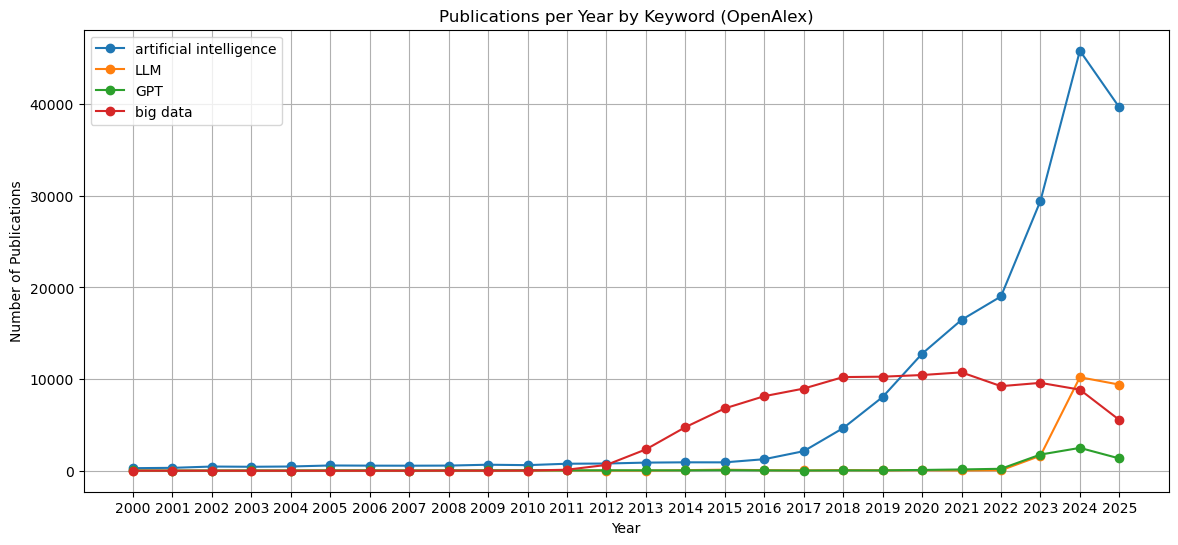

In [30]:
keywords = ["artificial intelligence", "LLM", "GPT", "big data"]
trend_data = {}

for kw in keywords:
    url_q4 = f"https://api.openalex.org/works?filter=title.search:\"{kw}\",from_publication_date:2000-01-01&group_by=publication_year&per_page=200"
    response_q4 = requests.get(url_q4).json()
    
    df_kw = pd.DataFrame(response_q4['group_by'])
    df_kw = df_kw.rename(columns={'key':'year','count':kw})
    df_kw = df_kw[['year', kw]]
    trend_data[kw] = df_kw

trend_df = trend_data[keywords[0]]
for kw in keywords[1:]:
    trend_df = pd.merge(trend_df, trend_data[kw], on='year', how='outer')

trend_df = trend_df.fillna(0).sort_values('year')
trend_df

# Visualization
plt.figure(figsize=(14,6))

for kw in keywords:
    plt.plot(trend_df['year'], trend_df[kw], label=kw, marker='o')

plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("Publications per Year by Keyword (OpenAlex)")
plt.legend()
plt.grid(True)
plt.show()